In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

DataSet = pd.read_csv(r"C:\Users\muham\Downloads\archive\Student_Performance.csv")
DataSet
DataSet["travel_time"]


0          <15 min
1          >60 min
2          <15 min
3        15-30 min
4        30-60 min
           ...    
24995    15-30 min
24996      <15 min
24997      <15 min
24998    15-30 min
24999    30-60 min
Name: travel_time, Length: 25000, dtype: str

## preproces the data using pip lines


In [5]:
DataSet.isnull().sum

<bound method DataFrame.sum of        student_id    age  gender  school_type  parent_education  study_hours  \
0           False  False   False        False             False        False   
1           False  False   False        False             False        False   
2           False  False   False        False             False        False   
3           False  False   False        False             False        False   
4           False  False   False        False             False        False   
...           ...    ...     ...          ...               ...          ...   
24995       False  False   False        False             False        False   
24996       False  False   False        False             False        False   
24997       False  False   False        False             False        False   
24998       False  False   False        False             False        False   
24999       False  False   False        False             False        False   

       a

In [6]:
DataSet.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

In [7]:
import seaborn as sns
import math
Catfeature=["student_id",	"age",	"gender",	"school_type"	,"parent_education",	"study_hours",	"attendance_percentage",	"internet_access",	"travel_time",	"extra_activities",	"study_method",	"math_score",	"science_score",	"english_score",	"overall_score",	"final_grade"]
n=len(Catfeature)
cols = 3
rows = math.ceil(n / cols)

In [8]:
# plt.figure(figsize=(15, 5 * rows))

# for i, feature in enumerate(Catfeature, 1):
#     plt.subplot(rows, cols, i)

#     sns.countplot(
#         x=feature,
#         hue='final_grade',
#         data=DataSet,
#         palette='Set2'
#     )

#     plt.title(f'{feature} vs student performance')

# plt.tight_layout()
# plt.show()

In [9]:
# X=DataSet.iloc[:,:-1]
# X

In [10]:
# X.shape

In [11]:
# Y=DataSet.iloc[:,-1:]
# Y

In [12]:
# Y.shape
CatFeaure=["gender",	"school_type",	"parent_education","extra_activities",	"study_method","final_grade"]

In [13]:
# pd.get_dummies(DataSet,columns=CatFeaure)

## using the sklearn one hot encoding


In [14]:
# import sklearn 
# from sklearn.preprocessing import OneHotEncoder
# encode=OneHotEncoder()
# col=["gender",	"school_type",	"parent_education","extra_activities",	"study_method","final_grade"]
# encoder=encode.fit_transform(DataSet[col])
# print(encoder.toarray())

In [15]:
# import sklearn 
# from sklearn.preprocessing import LabelEncoder
# encode=LabelEncoder()
# col=["gender",	"school_type",	"parent_education","extra_activities",	"study_method","final_grade","internet_access"]
# for col in col:
#     DataSet[col]=encode.fit_transform(DataSet[col])
#     print(DataSet.head())

## using piplines 

In [16]:
from sklearn.pipeline import Pipeline
X=DataSet.iloc[:,:-1]
X
Y=DataSet.iloc[:,-1]
print(Y)
DataSet["travel_time"] = DataSet["travel_time"].replace({
    "<15 min": 10,
    "15-30 min": 22,
    "30-60 min": 45,
    ">60 min": 75
})
from sklearn.tree import DecisionTreeClassifier

0        e
1        d
2        b
3        e
4        f
        ..
24995    e
24996    d
24997    f
24998    f
24999    f
Name: final_grade, Length: 25000, dtype: str


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
pip=Pipeline(steps=[
    'encoder',OneHotEncoder(handle_unknown='ignore'),
    'model',DecisionTreeClassifier()

])
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CatFeaure)])

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
from sklearn.metrics import accuracy_score,confusion_matrix


In [18]:
pipe=Pipeline([
    ('Oncode',OneHotEncoder(handle_unknown='ignore')),
    ('model',DecisionTreeClassifier())
])

In [19]:
pipe.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Oncode', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, defaul

In [20]:
y_prd=pipe.predict(X_test)
y_prd

array(['b', 'e', 'd', ..., 'e', 'a', 'e'], shape=(5000,), dtype=object)

In [21]:
acc=accuracy_score(Y_test,y_prd)
acc
cm = confusion_matrix(Y_test, y_prd)
cm

array([[ 204,   37,   15,    0,    0,    0],
       [  11,  513,   17,    1,    0,    0],
       [   4,   42, 1025,  122,    5,    0],
       [   0,    0,   60, 1087,  117,    4],
       [   0,    0,    7,  134,  920,   91],
       [   0,    0,    0,   12,  133,  439]])

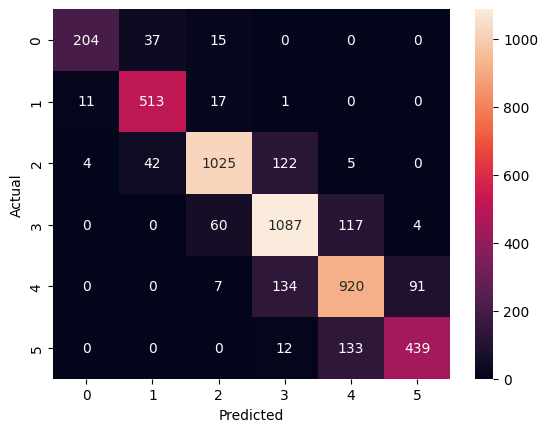

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## the model test on new data 

In [27]:
new_data = pd.DataFrame([{
    "age": 16,
    "gender": "male",
    "school_type": "public",
    "parent_education": "high_school",
    "study_hours": 3.5,
    "attendance_percentage": 85,
    "internet_access": "yes",
    "travel_time": "15-30 min",
    "extra_activities": "yes",
    "study_method": "group"
}])
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)
new_data = new_data[X_train.columns]

prediction = pipe.predict(new_data)
print(prediction)

['d']
